Original Dataset:
    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1     Sunny         Hot     High  Strong         No
2  Overcast         Hot     High    Weak        Yes
3      Rain        Mild     High    Weak        Yes
4      Rain        Cool   Normal    Weak        Yes
5      Rain        Cool   Normal  Strong         No
6  Overcast        Mild   Normal  Strong        Yes

Encoded Dataset:
   Outlook  Temperature  Humidity  Wind  PlayTennis
0        2            1         0     1           0
1        2            1         0     0           0
2        0            1         0     1           1
3        1            2         0     1           1
4        1            0         1     1           1
5        1            0         1     0           0
6        0            2         1     0           1

Encoding Details:
Outlook : {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Temperature : {'Cool': np.int64(0)

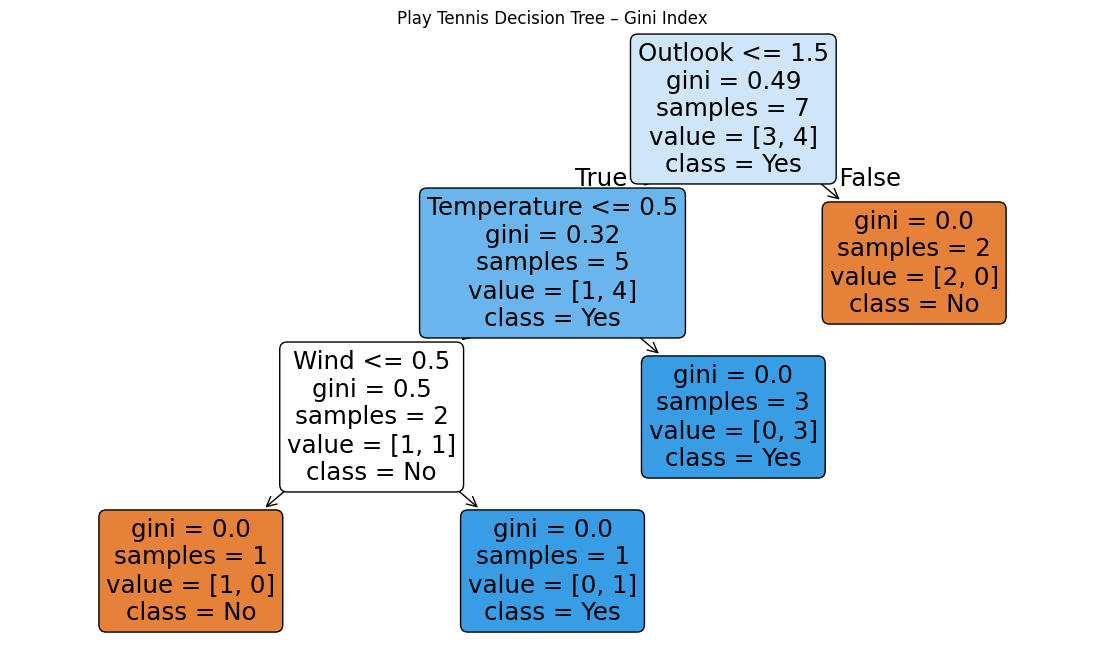

In [27]:
# -----------------------------------------
# STEP 1: Import required libraries
# -----------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score


# -----------------------------------------
# STEP 2: Create the Play Tennis dataset
# -----------------------------------------

data = {
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast',
        'Rain', 'Rain', 'Rain', 'Overcast'
    ],

    'Temperature': [
        'Hot', 'Hot', 'Hot',
        'Mild', 'Cool', 'Cool', 'Mild'
    ],

    'Humidity': [
        'High', 'High', 'High',
        'High', 'Normal', 'Normal', 'Normal'
    ],

    'Wind': [
        'Weak', 'Strong', 'Weak',
        'Weak', 'Weak', 'Strong', 'Strong'
    ],

    'PlayTennis': [
        'No', 'No', 'Yes',
        'Yes', 'Yes', 'No', 'Yes'
    ]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)


# -----------------------------------------
# STEP 3: Convert words into numbers
# -----------------------------------------

encoded_df = df.copy()
encoders = {}

for column in encoded_df.columns:
    encoder = LabelEncoder()

    encoded_df[column] = encoder.fit_transform(
        encoded_df[column]
    )

    encoders[column] = encoder


print("\nEncoded Dataset:")
print(encoded_df)


# Display how each word was encoded
print("\nEncoding Details:")

for column, encoder in encoders.items():
    print(column, ":", dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    ))


# -----------------------------------------
# STEP 4: Separate input and output
# -----------------------------------------

X = encoded_df.drop('PlayTennis', axis=1)
y = encoded_df['PlayTennis']

print("\nInput Features X:")
print(X)

print("\nOutput y:")
print(y)


# -----------------------------------------
# STEP 5: Create and train Decision Tree
# -----------------------------------------

model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

model.fit(X, y)

print("\nModel Trained Successfully")


# -----------------------------------------
# STEP 6: Print Decision Tree rules
# -----------------------------------------

tree_rules = export_text(
    model,
    feature_names=list(X.columns)
)

print("\nDecision Tree Rules:")
print(tree_rules)


# -----------------------------------------
# STEP 7: Check model accuracy
# -----------------------------------------

train_predictions = model.predict(X)

accuracy = accuracy_score(
    y,
    train_predictions
)

print("Training Accuracy:", accuracy)


# -----------------------------------------
# STEP 8: Predict a new weather condition
# -----------------------------------------

new_weather = pd.DataFrame({
    'Outlook': ['Overcast'],
    'Temperature': ['Mild'],
    'Humidity': ['High'],
    'Wind': ['Weak']
})

print("\nNew Weather Before Encoding:")
print(new_weather)


# Convert the new weather words into numbers
for column in new_weather.columns:
    new_weather[column] = encoders[column].transform(
        new_weather[column]
    )

print("\nNew Weather After Encoding:")
print(new_weather)


# Make prediction
prediction_number = model.predict(new_weather)


# Convert prediction number back to Yes or No
prediction_word = encoders[
    'PlayTennis'
].inverse_transform(prediction_number)

print("\nFinal Prediction:", prediction_word[0])


# -----------------------------------------
# STEP 9: Visualize the Decision Tree
# -----------------------------------------

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)

plt.title("Play Tennis Decision Tree – Gini Index")
plt.show()
